# ML Assignment 3 
**by Amit Ner Gaon**

# Utils

## Package Version Checks

Add folder to path in order to load from the check_packages.py script:

In [1]:
import sys
sys.path.insert(0, '..')

Check recommended package versions:

In [2]:
from src.python_environment_check import check_packages


d = {
    'numpy': '1.21.2',
    'matplotlib': '3.4.3',
    'sklearn': '1.0',
}
check_packages(d)

[OK] Your Python version is 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]
[OK] numpy 1.21.2
[OK] matplotlib 3.4.3
[OK] sklearn 1.0.2


In [3]:
from IPython.display import Image
%matplotlib inline


from pathlib import Path

## Obtaining and preparing the MNIST dataset

The MNIST dataset is publicly available at http://yann.lecun.com/exdb/mnist/ and consists of the following four parts:

- Training set images: train-images-idx3-ubyte.gz (9.9 MB, 47 MB unzipped, 60,000 examples)
- Training set labels: train-labels-idx1-ubyte.gz (29 KB, 60 KB unzipped, 60,000 labels)
- Test set images: t10k-images-idx3-ubyte.gz (1.6 MB, 7.8 MB, 10,000 examples)
- Test set labels: t10k-labels-idx1-ubyte.gz (5 KB, 10 KB unzipped, 10,000 labels)



In [4]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd


X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
print(f"X type: {type(X)}")
print(f"y type: {type(y)}")
X = X.values
y = y.astype(int).values

print("MNIST dataset loaded.")
print(f"X type: {type(X)}")
print(f"X shape: {X.shape}")
print(f"y type: {type(y)}")
print(f"y shape: {y.shape}")


X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>
MNIST dataset loaded.
X type: <class 'numpy.ndarray'>
X shape: (70000, 784)
y type: <class 'numpy.ndarray'>
y shape: (70000,)


Normalize to [-1, 1] range:

In [5]:
X = ((X / 255.) - .5) * 2

Visualize the first digit of each class:

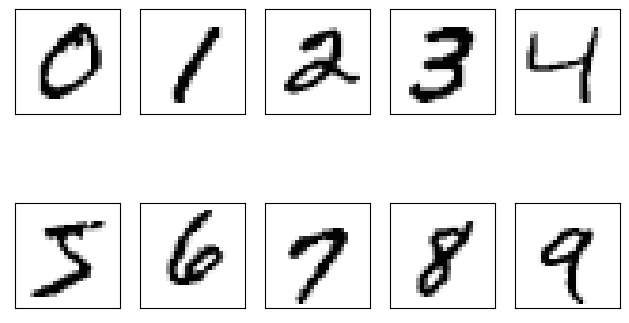

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
#plt.savefig('figures/11_4.png', dpi=300)
plt.show()

Visualize 25 different versions of "7":

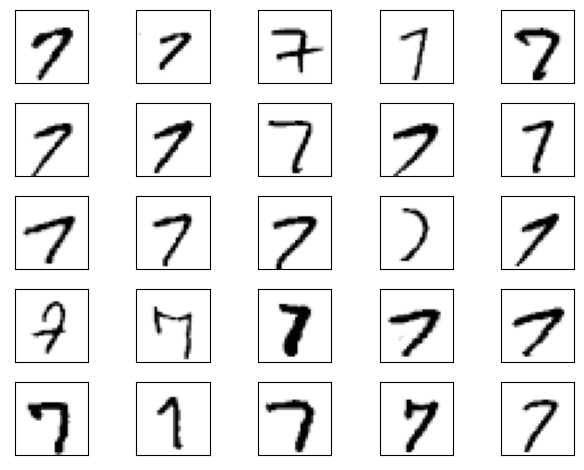

In [7]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
# plt.savefig('figures/11_5.png', dpi=300)
plt.show()

Split into training, validation, and test set:

In [8]:
from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, stratify=y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)


# optional to free up some memory by deleting non-used arrays:
del X_temp, y_temp

# Step 1 - Reading

Read chapter 11: [Implementing a Multi-layer Artificial Neural Network from Scratch](https://drive.google.com/file/d/1rzCDAkmLlOdqGciO7NnARlnahCeaqzFS/view) of the book “Machine Learning with PyTorch and Scikit-Learn” by Raschka et al. (2022)


# Step 2 - Implementing a Multi-Layer ANN

Extended chapter 11 code using numpy only. <br>
Classifying handwritten digits.


## Implementing a multi-layer perceptron

In [9]:
import numpy as np

In [10]:
##########################
### Utils
##########################

### One-hot encoding ###

def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


### activation functions ###
def activation_function_hidden_layer(z):
    return sigmoid(z)

def activation_function_derivative_hidden_layer(a):
    return sigmoid_derivative(a)


def activation_function_output_layer(z):
    return softmax(z)



# Sigmoid Activation
def sigmoid(z):                                        
    return 1. / (1. + np.exp(-z))

def sigmoid_derivative(a):
    """
    Derivative of sigmoid with respect to z,
    given the sigmoid activation a = sigmoid(z)
    """
    return a * (1. - a)


def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)



### loss functions ###
def loss_function(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def loss_function_derivative(y_true, y_pred):
    return mean_squared_error_derivative(y_true, y_pred)


# MSE Loss
def mean_squared_error(y_true, y_pred):
    n_examples = y_true.shape[0]
    return np.sum((y_true - y_pred) ** 2) / n_examples

def mean_squared_error_derivative(y_true, y_pred):  
    n_examples = y_true.shape[0]
    return (2.0 / n_examples) * (y_pred - y_true)




def softmax_mse_delta(y_true_onehot: np.ndarray,
                      y_pred_proba: np.ndarray) -> np.ndarray:
    """Computes the output-layer error term (delta) for
    softmax activation with mean squared error (MSE) loss.

    Args:
        y_true_onehot (np.ndarray): One-hot encoded true labels,
            shape (n_samples, num_classes).
        y_pred_proba (np.ndarray): Softmax output probabilities,
            shape (n_samples, num_classes).

    Returns:
        np.ndarray: Delta for the output layer,
            shape (n_samples, num_classes).
    """
    g = y_pred_proba - y_true_onehot
    return y_pred_proba * (g - np.sum(g * y_pred_proba, axis=1, keepdims=True))


In [11]:
class NeuralNetMLP:

    def __init__(self, num_features, hidden_layers, num_classes, random_seed=123):
        """Initializes a multi-layer perceptron (MLP) neural network.
        Args:
            num_features (int): Number of input features.
            hidden_layers (list[int]): Sizes of the hidden layers
                (e.g., [128, 64] for two hidden layers).
            num_classes (int): Number of output classes.
            random_seed (int, optional): Random seed for reproducibility.
                Defaults to 123.
        Returns:
            None
        """
        self.num_classes = num_classes
        # self.hidden_layers = hidden_layers

        rng = np.random.RandomState(random_seed)

        # ---- Build layer dimensions ----
        #              input layer     hidden layers    output dimensions (not a layer)
        layer_sizes = [num_features] + hidden_layers + [num_classes]
        print(f"[INIT] (output_dim, input_dim)")
        print(f"[INIT] Layer sizes: {layer_sizes}")

        # ---- Initialize weights & biases ----
        self.weights = []
        self.biases = []

        for i in range(len(layer_sizes) - 1): # output dimensions is not a layer
            self.weights.append(
                rng.normal(loc=0.0, scale=0.1,
                           #          output_dim     input_dim
                           size=(layer_sizes[i + 1], layer_sizes[i]))
            )
            print(f"[INIT] Initialized weights for layer {i} with shape {self.weights[-1].shape}")
            
            #                              output_dim
            self.biases.append(np.zeros(layer_sizes[i + 1]))


    ##### Forward ###### 
    def forward(self, x) -> list[np.ndarray]:
        """Performs a forward pass through the network.
        Args:
            x (np.ndarray): Input data of shape (n_samples, n_features).
        Returns:
            list[np.ndarray]: Activations of all layers (excluding input).
                Each element has shape (n_samples, n_units_in_layer).
                The last element corresponds to the output layer.
        """
        activations = []
        a = x   # input layer "activations" vector

        # print(f"[Forward] Input dimensions: {a.shape[1]}")


        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = np.dot(a, W.T) + b
            # print(f"[Forward] Layer {i} weights shape: {W.shape}")
            # print(f"[Forward] Layer {i}: z shape: {z.shape}")

            # output layer uses different activation function
            if i == len(self.weights) - 1:
                a = activation_function_output_layer(z)
            else:
                a = activation_function_hidden_layer(z)
            activations.append(a)


        return activations # the last element is the output of the network



    ##### Backward ######
    def backward(self, x, activations, y) -> tuple[list[np.ndarray], list[np.ndarray]]:
        """Performs backpropagation to compute gradients of the loss.
        Args:
            x (np.ndarray): Input batch of shape (n_samples, n_features).
            activations (list[np.ndarray]): Activations from the forward pass.
                Each element has shape (n_samples, n_units_in_layer).
                The last element corresponds to the output layer.
            y (np.ndarray): Ground-truth class labels of shape (n_samples,).
        Returns:
            tuple[list[np.ndarray], list[np.ndarray]]:
                - grads_w: Gradients of the loss with respect to weights.
                Each element has the same shape as the corresponding weight matrix.
                - grads_b: Gradients of the loss with respect to biases.
                Each element has the same shape as the corresponding bias vector.
        """
        y_onehot = int_to_onehot(y, self.num_classes)

        batch_size = x.shape[0]

        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)

        # Output layer
        a_out = activations[-1]
        delta = softmax_mse_delta(y_onehot, a_out)

        # print(f"[Backward] Output layer weights shape: {delta.shape}")

        # Backprop through layers
        for layer in reversed(range(len(self.weights))):

            # print(f"[Backward] Layer {layer} delta shape: {delta.shape}")
            a_prev = x if layer == 0 else activations[layer - 1]

            grads_w[layer] = np.dot(delta.T, a_prev) / batch_size
            grads_b[layer] = np.sum(delta, axis=0) / batch_size

            if layer > 0:
                a_h = activations[layer - 1]
                delta = np.dot(delta, self.weights[layer]) * activation_function_derivative_hidden_layer(a_h)

        return grads_w, grads_b

In [12]:
model = NeuralNetMLP(num_features=28*28,
                     hidden_layers=[500, 500],
                     num_classes=10)

[INIT] (output_dim, input_dim)
[INIT] Layer sizes: [784, 500, 500, 10]
[INIT] Initialized weights for layer 0 with shape (500, 784)
[INIT] Initialized weights for layer 1 with shape (500, 500)
[INIT] Initialized weights for layer 2 with shape (10, 500)


## Coding the neural network training loop

In [13]:
import numpy as np

### Defining data Loaders


In [14]:
# Parameters
num_epochs = 20
minibatch_size = 100

In [15]:
def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start_idx in range(0, indices.shape[0] - minibatch_size 
                           + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        
        yield X[batch_idx], y[batch_idx]

        
# iterate over training epochs
for i in range(num_epochs):

    # iterate over minibatches
    minibatch_gen = minibatch_generator(
        X_train, y_train, minibatch_size)
    
    for X_train_mini, y_train_mini in minibatch_gen:

        break
        
    break
    
print(X_train_mini.shape)
print(y_train_mini.shape)

(100, 784)
(100,)


Defining a function to compute the loss and accuracy

In [16]:
def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    return np.mean((onehot_targets - probas)**2)


def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets) 


probas = model.forward(X_valid)[-1]
init_valid_mse = mse_loss(y_valid, probas)

predicted_labels = np.argmax(probas, axis=1)
init_valid_acc = accuracy(y_valid, predicted_labels)

print(f'Initial validation MSE: {init_valid_mse:.4f}')
print(f'Initial validation accuracy: {init_valid_acc*100:.2f}%')

Initial validation MSE: 0.1291
Initial validation accuracy: 9.94%


In [17]:
from sklearn.metrics import roc_auc_score

def compute_mse_acc_auc(nnet, X, y, num_labels=10, minibatch_size=100) -> tuple[float, float, float]:
    mse, correct_pred, num_examples = 0., 0, 0
    all_probas = []
    all_targets = []
    minibatch_gen = minibatch_generator(X, y, minibatch_size)
        
    for i, (features, targets) in enumerate(minibatch_gen):

        probas = nnet.forward(features)[-1]
        predicted_labels = np.argmax(probas, axis=1)
        
        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()
        
        num_examples += targets.shape[0]
        mse += loss
        
        # Collect for AUC calculation
        all_probas.append(probas)
        all_targets.append(onehot_targets)

    mse = mse/(i+1)
    acc = correct_pred/num_examples
    
    # Calculate AUC
    all_probas = np.vstack(all_probas)
    all_targets = np.vstack(all_targets)
    macro_auc = roc_auc_score(all_targets, all_probas, multi_class='ovr', average='macro')
    
    return mse, acc, macro_auc

In [18]:
init_valid_mse, init_valid_acc, init_valid_auc = compute_mse_acc_auc(model, X_valid, y_valid)
print(f'Initial valid MSE: {init_valid_mse:.4f}')
print(f'Initial valid accuracy: {init_valid_acc*100:.2f}%')
print(f'Initial valid AUC: {init_valid_auc:.4f}')

Initial valid MSE: 0.1291
Initial valid accuracy: 9.94%
Initial valid AUC: 0.5264


In [ ]:
def train(model:NeuralNetMLP, X_train, y_train, X_valid, y_valid, num_epochs,
          learning_rate=0.1, minibatch_size = 100):
    
    # loss
    epoch_train_loss = []
    # accurecy
    epoch_train_acc = []
    epoch_valid_acc = []
    # AUC
    epoch_train_macro_auc = []
    epoch_valid_macro_auc = []
    
    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)
        

        for X_train_mini, y_train_mini in minibatch_gen:
            
            # w0_before = model.weights[0].copy() # for debugging

            #### Compute outputs ####
            activations = model.forward(X_train_mini)
            
            #### Compute gradients ####
            grads_w, grads_b = model.backward(X_train_mini, activations, y_train_mini)
            #### Update weights ####
            for i in range(len(model.weights)):
                model.weights[i] -= learning_rate * grads_w[i]
                # print(f"[TRAIN] Updated weights for layer {i} with total sum {grads_w[i].sum()}")
                model.biases[i] -= learning_rate * grads_b[i]
                # print(f"[TRAIN] Updated biases for layer {i} with total sum {grads_b[i].sum()}")


        #### Metrics ####        
        train_mse, train_acc, train_macro_auc = compute_mse_acc_auc(model, X_train, y_train)
        valid_mse, valid_acc, valid_macro_auc = compute_mse_acc_auc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100

        #### Epoch Logging ####        
        epoch_train_loss.append(train_mse)
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_train_macro_auc.append(train_macro_auc)
        epoch_valid_macro_auc.append(valid_macro_auc)

        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.4f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%'
        )

    return epoch_train_loss, epoch_train_acc, epoch_valid_acc, epoch_train_macro_auc, epoch_valid_macro_auc

# Step 3 - Evaluating the ANN Performance

Apply the code of section 2 with the two layers for classifying handwritten digits MNIST dataset.

In [20]:
np.random.seed(123) # for the training set shuffling

epoch_train_loss, epoch_train_acc, epoch_valid_acc, epoch_train_macro_auc, epoch_valid_macro_auc = train(
    model, X_train, y_train, X_valid, y_valid,
    num_epochs=50, learning_rate=0.1, minibatch_size = minibatch_size)

Epoch: 001/050 | Train MSE: 0.04 | Train Acc: 75.69% | Valid Acc: 76.16%
Epoch: 002/050 | Train MSE: 0.03 | Train Acc: 86.12% | Valid Acc: 85.58%
Epoch: 003/050 | Train MSE: 0.02 | Train Acc: 88.24% | Valid Acc: 88.46%
Epoch: 004/050 | Train MSE: 0.02 | Train Acc: 89.44% | Valid Acc: 89.22%
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 90.12% | Valid Acc: 90.10%
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 90.48% | Valid Acc: 90.68%
Epoch: 007/050 | Train MSE: 0.01 | Train Acc: 91.06% | Valid Acc: 91.14%
Epoch: 008/050 | Train MSE: 0.01 | Train Acc: 91.40% | Valid Acc: 91.30%
Epoch: 009/050 | Train MSE: 0.01 | Train Acc: 91.81% | Valid Acc: 91.52%
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 92.01% | Valid Acc: 91.86%
Epoch: 011/050 | Train MSE: 0.01 | Train Acc: 92.16% | Valid Acc: 91.86%
Epoch: 012/050 | Train MSE: 0.01 | Train Acc: 92.40% | Valid Acc: 92.26%
Epoch: 013/050 | Train MSE: 0.01 | Train Acc: 92.76% | Valid Acc: 92.56%
Epoch: 014/050 | Train MSE: 0.01 | Train Acc: 92.83

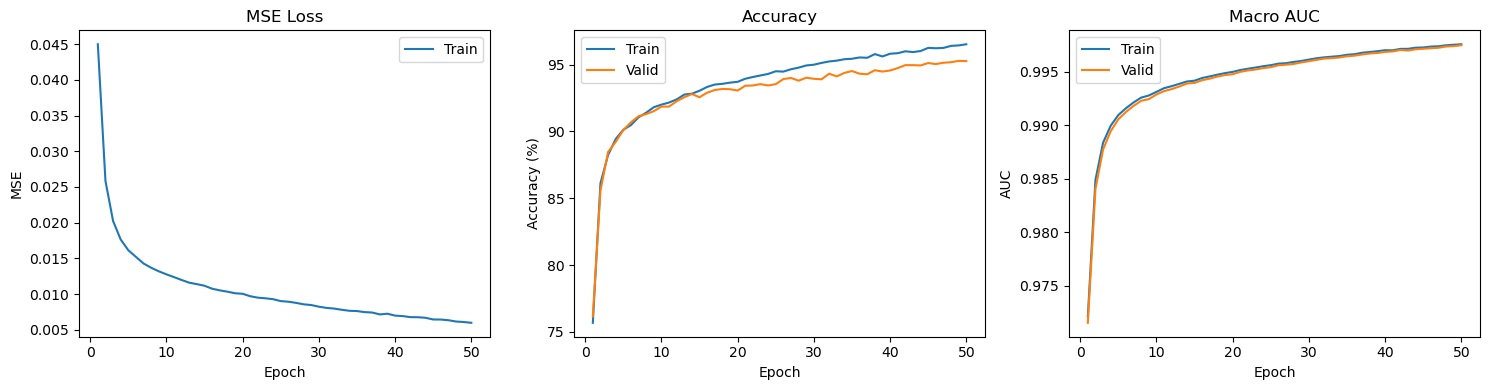

In [21]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(epoch_train_loss) + 1)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# 1) Loss (MSE)
axs[0].plot(epochs, epoch_train_loss, label="Train")
axs[0].set_title("MSE Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("MSE")
axs[0].legend()

# 2) Accuracy
axs[1].plot(epochs, epoch_train_acc, label="Train")
axs[1].plot(epochs, epoch_valid_acc, label="Valid")
axs[1].set_title("Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy (%)")
axs[1].legend()

# 3) Macro AUC
axs[2].plot(epochs, epoch_train_macro_auc, label="Train")
axs[2].plot(epochs, epoch_valid_macro_auc, label="Valid")
axs[2].set_title("Macro AUC")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("AUC")
axs[2].legend()

plt.tight_layout()

plt.savefig(
    "../docs/figures/NeuralNetMLP_training_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


In [22]:
test_mse, test_acc, test_macro_auc = compute_mse_acc_auc(model, X_test, y_test)

print(f'Test accuracy: {test_acc*100:.2f}%')
print(f'Test MSE: {test_mse:.4f}')
print(f'Test AUC: {test_macro_auc:.4f}')

Test accuracy: 95.25%
Test MSE: 0.0075
Test AUC: 0.9969


## Plot failure cases:

In [23]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]

probas = model.forward(X_test_subset)[-1]
test_pred = np.argmax(probas, axis=1)

misclassified_images = X_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]

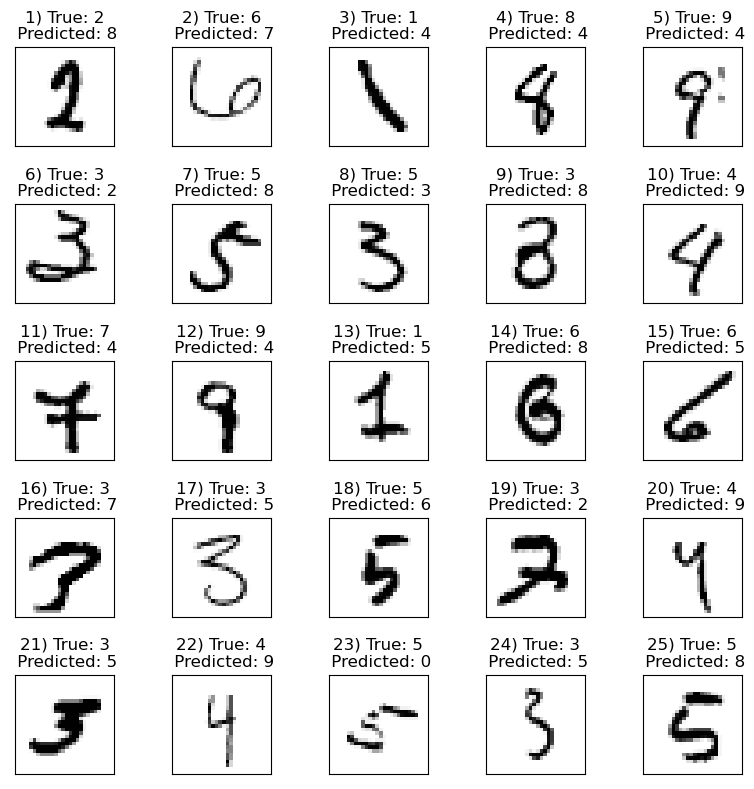

In [24]:
fig, ax = plt.subplots(nrows=5, ncols=5, 
                       sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title(f'{i+1}) '
                    f'True: {correct_labels[i]}\n'
                    f' Predicted: {misclassified_labels[i]}')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
#plt.savefig('figures/11_09.png', dpi=300)
plt.show()

In [25]:
final_test_mse, final_test_acc, final_test_macro_auc = compute_mse_acc_auc(model, X_test, y_test)
print(f'Final test MSE: {final_test_mse:.4f}')
print(f'Final test accuracy: {final_test_acc*100:.2f}%')
print(f'Final test macro AUC: {final_test_macro_auc:.4}')

Final test MSE: 0.0075
Final test accuracy: 95.25%
Final test macro AUC: 0.9969


# Step 4 - Compere to *Keras* Fully Connected ANN 

In [26]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import SGD

import tensorflow as tf

from typing import Tuple


2026-01-19 22:03:18.774093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768852998.838692 4019516 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768852998.868112 4019516 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [27]:
def build_ann(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    num_hidden_layers: int = 2,
    units_per_layer: int = 500,
    number_output_classes: int = 10,
    validation_split: float = 0.2,
    batch_size: int = 100,
    epochs: int = 20,
    learning_rate: float = 0.1,
) -> Tuple[Sequential, keras.callbacks.History]:
    """Builds and trains an ANN according to Task #1 specifications.
    Args:
        X_train (pd.DataFrame): Training features of shape (n_samples, n_features).
        y_train (pd.Series): Training labels as integer class ids (0..9).
        num_hidden_layers (int): Number of hidden layers. Defaults to 2.
        units_per_layer (int): Units per hidden layer. Defaults to 500.
        number_output_classes (int): Number of classes. Defaults to 10.
        validation_split (float): Fraction of training data used for validation.
            Defaults to 0.2.
        batch_size (int): Training batch size. Defaults to 100.
        epochs (int): Number of epochs. Defaults to 20.
        learning_rate (float): SGD learning rate. Defaults to 0.1.
    Returns:
        Tuple[Sequential, keras.callbacks.History]:
            The trained model and the training history.
    """

    # One-hot targets for MSE
    y_train = keras.utils.to_categorical(y_train, num_classes=number_output_classes)

    # Initialize the model
    classifier_ann = Sequential()

    # Input layer
    classifier_ann.add(Input(shape=(X_train.shape[1],)))

    # Hidden layers
    for i in range(num_hidden_layers):
        classifier_ann.add(Dense(units_per_layer, activation="sigmoid", name=f"hidden_{i+1}"))

    # Output layer
    classifier_ann.add(Dense(number_output_classes, activation="softmax", name="output"))

    # Compile


    macro_auc = tf.keras.metrics.AUC(
    name="macro_auc",
    multi_label=True,
    num_labels=number_output_classes,
    curve="ROC",
    summation_method="interpolation"
)

    classifier_ann.compile(
        optimizer=SGD(learning_rate=learning_rate),
        loss="mse",
        metrics=["accuracy", macro_auc],
    )

    # Train
    history = classifier_ann.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_split=validation_split,
    )

    return classifier_ann, history


In [28]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Plot training curves (Accuracy, Macro AUC, Loss).

    Args:
        history: keras History object returned by model.fit()
    """
    epochs = range(1, len(history.history["accuracy"]) + 1)

    plt.figure(figsize=(18, 4))

    # Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history.history["accuracy"], label="Train")
    if "val_accuracy" in history.history:
        plt.plot(epochs, history.history["val_accuracy"], label="Valid")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    # Macro AUC
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history.history["macro_auc"], label="Train")
    if "val_macro_auc" in history.history:
        plt.plot(epochs, history.history["val_macro_auc"], label="Valid")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title("Macro AUC")
    plt.legend()

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history.history["loss"], label="Train")
    if "val_loss" in history.history:
        plt.plot(epochs, history.history["val_loss"], label="Valid")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MSE Loss")
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        "../docs/figures/keras_training_history.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


In [29]:
classifier_ann, ann_history = build_ann(
    X_train=X,
    y_train=y,
    num_hidden_layers=2,
    units_per_layer=500,
    number_output_classes=10,
    batch_size=100,
    epochs=20,
    validation_split=0.2
)

2026-01-19 22:03:29.072376: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.1399 - loss: 0.0902 - macro_auc: 0.5702 - val_accuracy: 0.2304 - val_loss: 0.0888 - val_macro_auc: 0.8262
Epoch 2/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2560 - loss: 0.0885 - macro_auc: 0.8047 - val_accuracy: 0.3327 - val_loss: 0.0874 - val_macro_auc: 0.9079
Epoch 3/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3605 - loss: 0.0871 - macro_auc: 0.8885 - val_accuracy: 0.3759 - val_loss: 0.0857 - val_macro_auc: 0.9347
Epoch 4/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3814 - loss: 0.0852 - macro_auc: 0.9152 - val_accuracy: 0.4049 - val_loss: 0.0831 - val_macro_auc: 0.9451
Epoch 5/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4027 - loss: 0.0824 - macro_auc: 0.9332 - val_accuracy: 0.4251 - val_loss: 0.0793 - val_macro_auc: 0.9515
Epoch 6/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4401 - loss: 0.0784 - macro_auc: 0.9409 - val_accuracy: 0.5096 - val_loss:

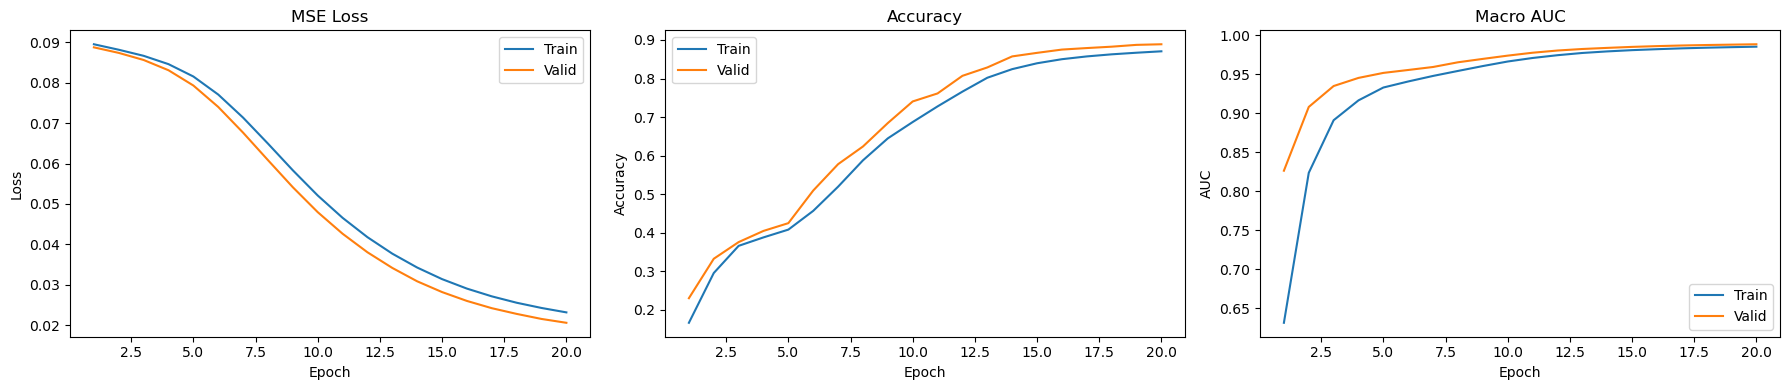

In [30]:
plot_training_history(ann_history)

In [31]:
from typing import Tuple
import numpy as np
from sklearn.metrics import roc_auc_score
from tensorflow import keras

def compute_mse_acc_auc_keras(
    model: keras.Model,
    X_test: np.ndarray,
    y_test: np.ndarray,
    num_classes: int = 10,
) -> Tuple[float, float, float]:
    """
    Computes Mean Squared Error (MSE), accuracy, and macro AUC (OVR) on a test set.

    Args:
        model (keras.Model): Trained Keras model.
        X_test (np.ndarray): Test features.
        y_test (np.ndarray): Test labels as integer class ids (0..num_classes-1).
        num_classes (int): Number of output classes.

    Returns:
        Tuple[float, float, float]:
            - mse: Mean Squared Error over the test set.
            - acc: Classification accuracy over the test set (0..1).
            - macro_auc: Macro-averaged ROC AUC using one-vs-rest.
    """
    # Predict class probabilities
    probas = model.predict(X_test, verbose=1)

    # One-hot encode true labels
    y_true_oh = keras.utils.to_categorical(y_test, num_classes=num_classes)

    # Mean Squared Error
    mse = np.mean((y_true_oh - probas) ** 2)

    # Accuracy
    y_pred = np.argmax(probas, axis=1)
    acc = np.mean(y_pred == y_test)

    # Macro AUC (OVR)
    macro_auc = roc_auc_score(
        y_true_oh,
        probas,
        multi_class="ovr",
        average="macro",
        labels=np.arange(num_classes),
    )

    print(f"Test MSE: {mse:.4f}")
    print(f"Test accuracy: {acc*100:.2f}%")
    print(f"Test macro AUC: {macro_auc:.4f}")

    return mse, acc, macro_auc


In [32]:
compute_mse_acc_auc_keras(
    model=classifier_ann,
    X_test=X_test,
    y_test=y_test,
    num_classes=10,
)

657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Test MSE: 0.0224
Test accuracy: 87.51%
Test macro AUC: 0.9855


(0.022417512407763154, 0.8751428571428571, 0.9854999246379854)

<br>
<br>